1. Import librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from pathlib import Path


2.Import documents

In [2]:
#name = pd.read_csv(r"imdb\name.basics.tsv",  sep="\t",na_values='\\N', usecols=['nconst', 'primaryName', 'knownForTitles']) 
name = pd.read_csv(r"..\..\data\raw\imdb\name.basics.tsv", sep="\t", na_values='\\N', usecols=['nconst', 'primaryName', 'knownForTitles'])


In [4]:
display(name.describe())

,nconst,primaryName,knownForTitles
count,15225343,15225264,13410531
unique,15225343,11609994,6272025
top,nm0000001,Alex,tt0123338
freq,1,593,8293


In [5]:
title = pd.read_csv(r'..\..\data\raw\imdb\title.basics.tsv',sep='\t',na_values='\\N',usecols=['tconst', 'titleType', 'primaryTitle', 'runtimeMinutes', 'startYear', 'genres'],on_bad_lines='skip',engine='python')
title = title[title['titleType'] == 'movie']

In [6]:
Principal = pd.read_csv(r'..\..\data\raw\imdb\title.principals.tsv', sep='\t', na_values='\\N', usecols=['tconst', 'nconst', 'category'])

In [7]:
Ratings = pd.read_csv(r'..\..\data\raw\imdb\title.ratings.tsv', sep='\t',na_values='\\N')

3 Merge df_films et df_cast 

In [8]:
df_films = title.merge(Ratings, on='tconst',how='left')
df_cast = Principal.merge(name, on='nconst', how='left')
df_cast = df_cast[df_cast['tconst'].isin(df_films['tconst'])]

In [10]:
print(f'Films shape {df_films.shape}')
print(f'Casting shape:{df_cast.shape}')



Films shape (742654, 8)
Casting shape:(8551946, 5)


In [11]:
df_films.head(10)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894.0,45.0,Romance,5.3,236.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897.0,100.0,"Documentary,News,Sport",5.3,600.0
2,tt0000502,movie,Bohemios,1905.0,100.0,NaN,3.5,26.0
3,tt0000574,movie,The Story of the Kelly Gang,1906.0,70.0,"Action,Adventure,Biography",6.0,1067.0
4,tt0000591,movie,The Prodigal Son,1907.0,90.0,Drama,5.0,39.0
5,tt0000615,movie,Robbery Under Arms,1907.0,NaN,Drama,3.4,34.0
6,tt0000630,movie,Hamlet,1908.0,NaN,Drama,3.2,40.0
7,tt0000675,movie,Don Quijote,1908.0,NaN,Drama,4.1,30.0
8,tt0000679,movie,The Fairylogue and Radio-Plays,1908.0,120.0,"Adventure,Fantasy",5.0,85.0
9,tt0000838,movie,A Cultura do Cacau,1909.0,NaN,NaN,2.8,18.0


In [12]:
df_films.isna().sum()
print(f"Nan runtimeMinutes: {df_films['runtimeMinutes'].isna().mean()*100:.1f}%de NaN")
print(f"Nan averageRatings: {df_films['averageRating'].isna().mean()*100:.1f}%de NaN")
print(f"Nan numVotes: {df_films['numVotes'].isna().mean()*100:.1f}%de NaN")
print(f"Nan genres: {df_films['genres'].isna().mean()*100:.1f}%de NaN")
print(f"Nan startYear: {df_films['startYear'].isna().mean()*100:.1f}%de NaN")

print(f"Total ligne: {len(df_films)}")

Nan runtimeMinutes: 36.9%de NaN
Nan averageRatings: 54.0%de NaN
Nan numVotes: 54.0%de NaN
Nan genres: 10.5%de NaN
Nan startYear: 15.0%de NaN
Total ligne: 742654


54% de NA sur averageRating ainsi que numVotes, aucun interet de garder des films sans votes , on supprime

In [20]:
df_films = df_films.dropna(subset='averageRating')
df_films = df_films.dropna(subset='numVotes')

df_films.shape

(341961, 8)

Nous passons de 742654 films a 341961 films après suppression de NA sur la colonne averageRating et numVotes

<Axes: xlabel='averageRating', ylabel='Count'>

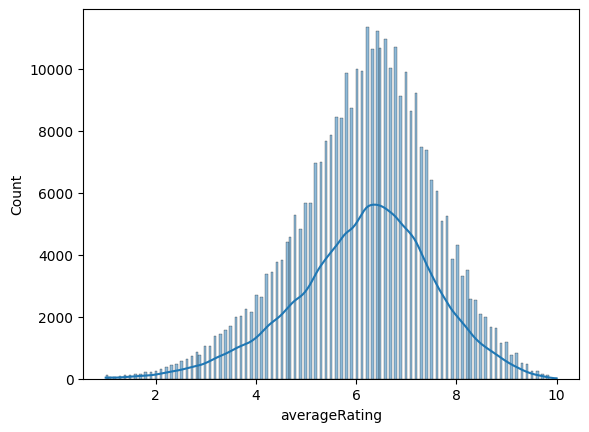

In [21]:
sns.histplot(data=df_films['averageRating'], kde=True)
#Nous avons une note moyenne de 6.5

<Axes: xlabel='startYear'>

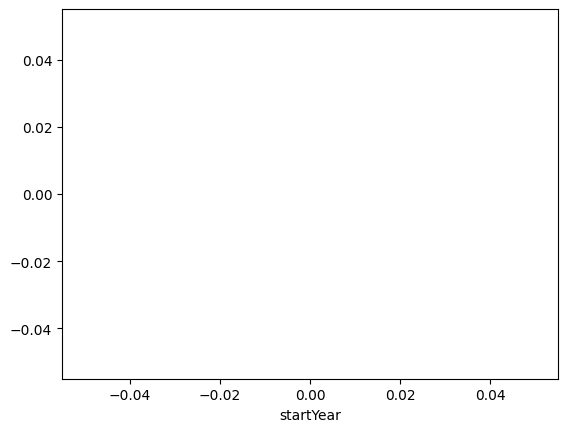

In [22]:
df_films[df_films['averageRating'].isna()].groupby('startYear').size().plot()

In [23]:
df_films.to_csv('df_films_clean.csv', index=False)